In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
json_path = "msd_ccd_results.json"

# JSON 읽기
with open(json_path, "r", encoding="utf-8") as f:
    results = json.load(f)

# DataFrame 변환
df_all = pd.json_normalize(results)

# 컬럼명 정리
df_all.columns = [col.replace(".", "_") for col in df_all.columns]

# signals 제외한 분석용 테이블
df_metrics = df_all[[c for c in df_all.columns if not c.startswith("signals_")]].copy()

print("=== df_all columns ===")
print(df_all.columns.tolist())

print("\n=== df_metrics head ===")
print(df_metrics.head())

# 저장
df_metrics.to_csv("msd_ccd_results_metrics.csv", index=False, encoding="utf-8-sig")

=== df_all columns ===
['sample_id', 'coded_factors_Kp', 'coded_factors_Ki', 'coded_factors_Kd', 'params_Kp', 'params_Ki', 'params_Kd', 'params_m', 'params_c', 'params_k', 'position_metrics_RiseTime', 'position_metrics_TransientTime', 'position_metrics_SettlingTime', 'position_metrics_SettlingMin', 'position_metrics_SettlingMax', 'position_metrics_Overshoot', 'position_metrics_Undershoot', 'position_metrics_Peak', 'position_metrics_PeakTime']

=== df_metrics head ===
   sample_id  coded_factors_Kp  coded_factors_Ki  coded_factors_Kd  params_Kp  \
0          0              -1.0              -1.0              -1.0        5.0   
1          1              -1.0              -1.0               1.0        5.0   
2          2              -1.0               1.0              -1.0        5.0   
3          3              -1.0               1.0               1.0        5.0   
4          4               1.0              -1.0              -1.0       20.0   

   params_Ki  params_Kd  params_m  params

In [12]:
df_metrics.corr('spearman')[["params_Kp", "params_Ki", "params_Kd"]]

,params_Kp,params_Ki,params_Kd
sample_id,0.177951,0.080546,0.031844
coded_factors_Kp,1.000000,0.000000,0.000000
coded_factors_Ki,0.000000,1.000000,0.000000
coded_factors_Kd,0.000000,0.000000,1.000000
params_Kp,1.000000,0.000000,0.000000
params_Ki,0.000000,1.000000,0.000000
params_Kd,0.000000,0.000000,1.000000
params_m,NaN,NaN,NaN
params_c,NaN,NaN,NaN
params_k,NaN,NaN,NaN


In [13]:
feature_cols = [
    "params_Kp",
    "params_Ki",
    "params_Kd",
]

target_cols = [
    "position_metrics_RiseTime",
    "position_metrics_SettlingTime",
    "position_metrics_Overshoot",
    "position_metrics_PeakTime",
    "position_metrics_Peak",
]

df_plot = df_metrics[feature_cols + target_cols].copy()
print(df_plot.head())

   params_Kp  params_Ki  params_Kd  position_metrics_RiseTime  \
0        5.0        1.0        0.1                  13.718257   
1        5.0        1.0        5.0                  14.288083   
2        5.0       15.0        0.1                   0.474680   
3        5.0       15.0        5.0                   1.276945   
4       20.0        1.0        0.1                   0.278300   

   position_metrics_SettlingTime  position_metrics_Overshoot  \
0                      24.056120                    0.000000   
1                      24.115195                    0.000052   
2                      14.665109                   42.959450   
3                       3.554010                    4.197981   
4                      23.151332                   29.950517   

   position_metrics_PeakTime  position_metrics_Peak  
0                  30.000000               0.976610  
1                  29.984801               0.978005  
2                   1.150706               1.430207  
3       

In [16]:
corr = df_plot.corr(numeric_only=True)
print(corr)

                                  params_Kp     params_Ki     params_Kd  \
params_Kp                      1.000000e+00  8.174023e-18  1.415736e-17   
params_Ki                      8.174023e-18  1.000000e+00  0.000000e+00   
params_Kd                      1.415736e-17  0.000000e+00  1.000000e+00   
position_metrics_RiseTime     -4.282366e-01 -5.918026e-01  7.084755e-02   
position_metrics_SettlingTime -7.897432e-02 -7.312422e-01 -3.505278e-01   
position_metrics_Overshoot     2.502920e-02  1.432308e-01 -6.665638e-01   
position_metrics_PeakTime     -1.620474e-01 -3.362371e-01  1.337687e-01   
position_metrics_Peak          6.812460e-05 -4.661278e-01 -7.282882e-03   

                               position_metrics_RiseTime  \
params_Kp                                      -0.428237   
params_Ki                                      -0.591803   
params_Kd                                       0.070848   
position_metrics_RiseTime                       1.000000   
position_metrics_Settlin

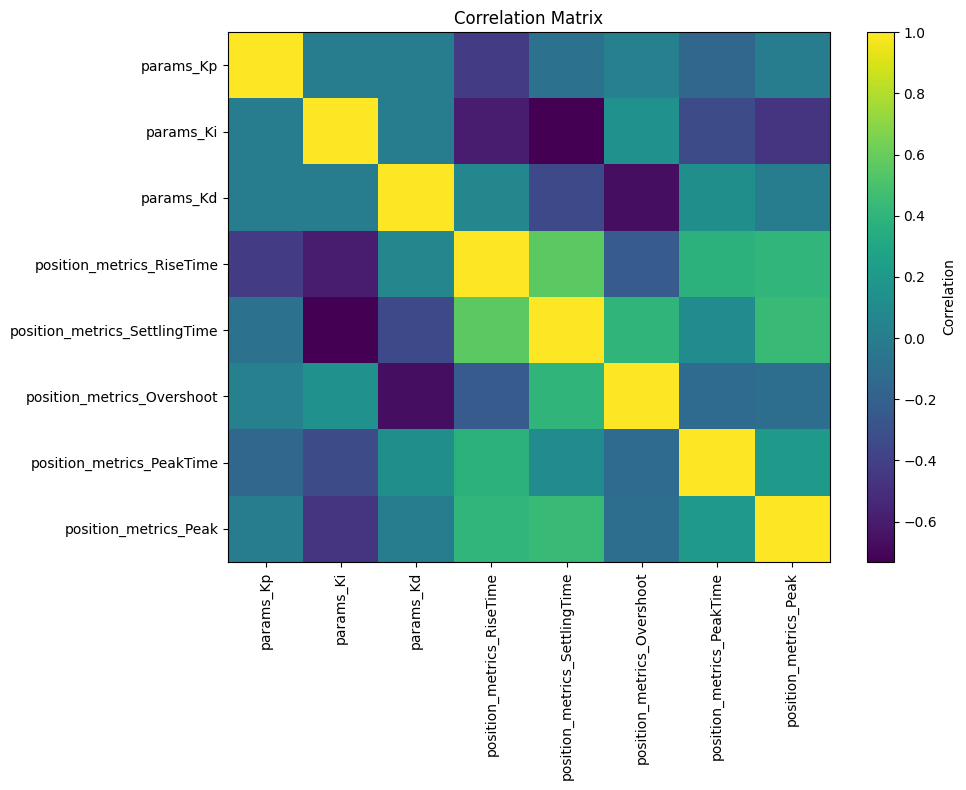

In [17]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()